In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Install all dependencies
!pip install xgboost shap -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib, json
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report
import xgboost as xgb
import shap

np.random.seed(42)
N = 5000

print("All libraries loaded successfully!")

All libraries loaded successfully!


Data loading

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/transplant dataset.csv')

In [ ]:
df.head()

,Patient_ID,Patient_Age,Patient_Weight,Patient_BMI,Patient_BloodType,Organ_Required,Diagnosis_Result,Biological_Markers,Organ_Status,Donor_ID,...,Donor_Min_Age,Donor_Max_Age,Donor_Min_Weight,Donor_Max_Weight,Match_Status,RealTime_Organ_HealthScore,Organ_Condition_Alert,Predicted_Survival_Chance,Organ_Tracking_ID,Timestamp_Organ_Scanned
0,P5501,37,69.97,25.64,AB,Kidney,CKD Stage 4,1.44,Transplanted,D7614,...,18,70,45,85,No,0.74,Critical,74.27,ORG35915,07-06-2025 02:18
1,P5030,56,62.99,18.19,O,Kidney,CKD Stage 5,6.86,Matched,D6630,...,18,70,45,85,No,0.95,Normal,73.03,ORG46211,01-06-2025 23:18
2,P9740,37,87.29,24.22,AB,Kidney,ESRD,5.95,Pending,D4479,...,18,70,45,85,Yes,0.70,Critical,83.17,ORG16995,05-06-2025 22:33
3,P1880,36,60.17,19.04,B,Kidney,CKD Stage 4,9.24,Transplanted,D6327,...,18,70,45,85,Yes,0.75,Critical,74.07,ORG92811,06-06-2025 20:30
4,P3285,72,64.32,26.64,AB,Kidney,CKD Stage 4,2.73,Transplanted,D1831,...,18,70,45,85,Yes,0.63,Critical,92.01,ORG74241,04-06-2025 20:13


## Data Exploration (EDA)

In [ ]:
# Display basic DataFrame information
print(f"Shape: {df.shape}")
print(f"\nColumn types:\n{df.dtypes}")
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nAvailable columns:\n{df.columns.tolist()}")
print(f"\nTarget distribution (Predicted Survival Chance):\n{df['Predicted_Survival_Chance'].value_counts(normalize=True)}")

# Create a binary target variable for classification plots (e.g., graft survival)
df['graft_survival_1yr_binary'] = (df['Predicted_Survival_Chance'] > df['Predicted_Survival_Chance'].median()).astype(int)
print(f"\nBinary Target distribution (Graft Survival 1yr):\n{df['graft_survival_1yr_binary'].value_counts(normalize=True)}")

Shape: (1000, 25)

Column types:
Patient_ID                     object
Patient_Age                     int64
Patient_Weight                float64
Patient_BMI                   float64
Patient_BloodType              object
Organ_Required                 object
Diagnosis_Result               object
Biological_Markers            float64
Organ_Status                   object
Donor_ID                       object
Donor_Age                       int64
Donor_Weight                  float64
Donor_BloodType                object
Organ_Donated                  object
Donor_Medical_Approval         object
Donor_Min_Age                   int64
Donor_Max_Age                   int64
Donor_Min_Weight                int64
Donor_Max_Weight                int64
Match_Status                   object
RealTime_Organ_HealthScore    float64
Organ_Condition_Alert          object
Predicted_Survival_Chance     float64
Organ_Tracking_ID              object
Timestamp_Organ_Scanned        object
dtype: object

Mi

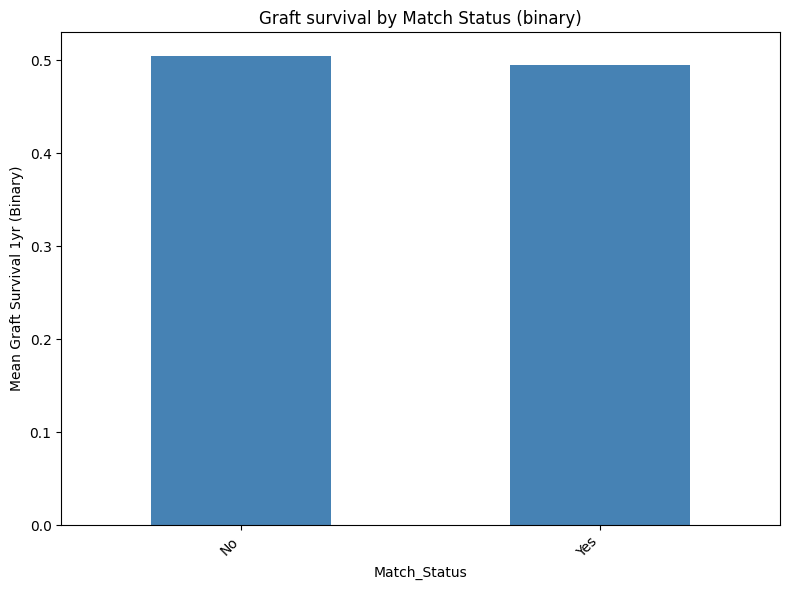

In [ ]:
# Plot: Graft survival by Match Status
fig, ax = plt.subplots(figsize=(8, 6))
df.groupby('Match_Status')['graft_survival_1yr_binary'].mean().plot(
    kind='bar', ax=ax, title='Graft survival by Match Status (binary)', color='steelblue')
plt.ylabel('Mean Graft Survival 1yr (Binary)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

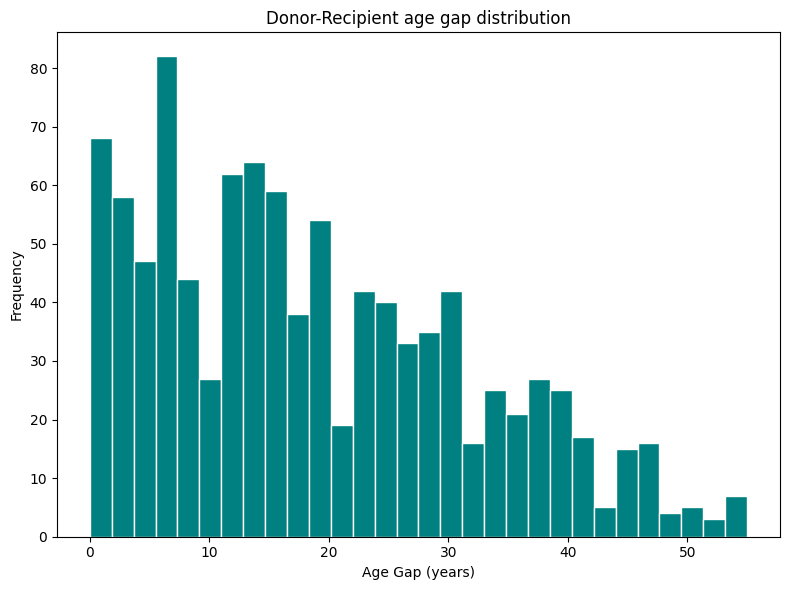

In [ ]:
# Plot: Donor-Recipient age gap distribution
df['age_gap'] = abs(df['Donor_Age'] - df['Patient_Age'])
fig, ax = plt.subplots(figsize=(8, 6))
ax.hist(df['age_gap'], bins=30, color='teal', edgecolor='white')
ax.set_title('Donor-Recipient age gap distribution')
ax.set_xlabel('Age Gap (years)')
ax.set_ylabel('Frequency')
plt.tight_layout()
plt.show()

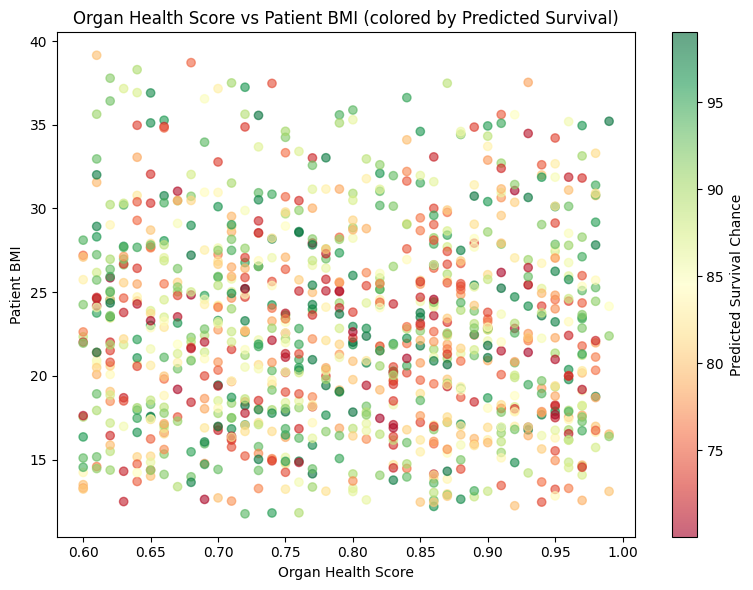

In [ ]:
# Plot: Organ Health Score vs Patient BMI (colored by Predicted Survival)
fig, ax = plt.subplots(figsize=(8 , 6))
scatter = ax.scatter(df['RealTime_Organ_HealthScore'], df['Patient_BMI'],
                  c=df['Predicted_Survival_Chance'], cmap='RdYlGn', alpha=0.6)
ax.set_title('Organ Health Score vs Patient BMI (colored by Predicted Survival)')
ax.set_xlabel('Organ Health Score')
ax.set_ylabel('Patient BMI')
plt.colorbar(scatter, label='Predicted Survival Chance')
plt.tight_layout()
plt.show()

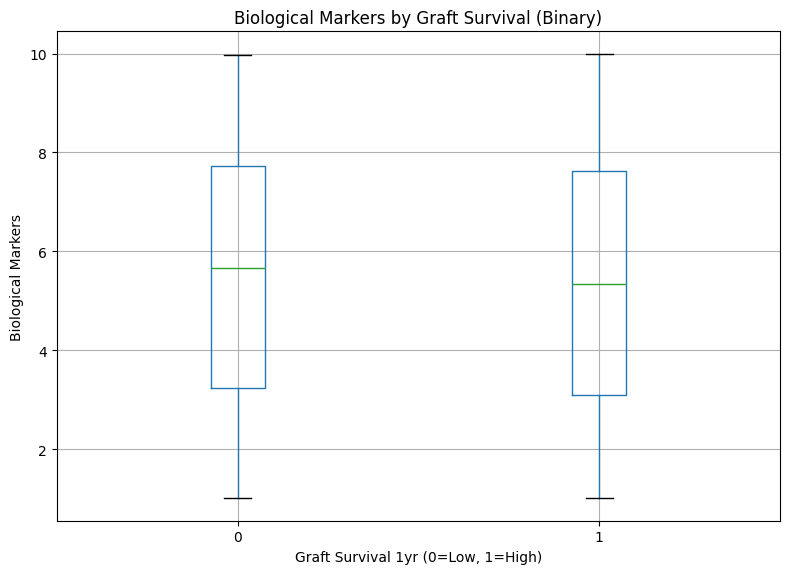

In [ ]:
# Plot: Biological Markers by outcome (binary graft survival)
fig, ax = plt.subplots(figsize=(8, 6))
df.boxplot(column='Biological_Markers', by='graft_survival_1yr_binary', ax=ax)
plt.suptitle('') # Suppress automatic suptitle from boxplot
ax.set_title('Biological Markers by Graft Survival (Binary)')
ax.set_xlabel('Graft Survival 1yr (0=Low, 1=High)')
ax.set_ylabel('Biological Markers')
plt.tight_layout()
plt.show()

In [ ]:
# ── Generate realistic donor-patient pairs ────────────────
blood_types  = ['A', 'B', 'AB', 'O']
blood_probs  = [0.42, 0.10, 0.04, 0.44]

patient_age     = np.random.randint(18, 75, N)
patient_weight  = np.random.uniform(45, 110, N).round(1)
patient_bmi     = (patient_weight / ((np.random.uniform(1.5, 1.9, N)) ** 2)).round(1)
donor_age       = np.random.randint(18, 70, N)
donor_weight    = np.random.uniform(45, 110, N).round(1)
patient_blood   = np.random.choice(blood_types, N, p=blood_probs)
donor_blood     = np.random.choice(blood_types, N, p=blood_probs)
health_score    = np.random.uniform(1, 10, N).round(2)
bio_markers     = np.random.uniform(1, 10, N).round(2)
donor_min_age   = np.clip(patient_age - 15, 18, 60).astype(int)
donor_max_age   = np.clip(patient_age + 15, 30, 75).astype(int)
donor_min_wt    = np.clip(patient_weight - 20, 40, 80).astype(int)
donor_max_wt    = np.clip(patient_weight + 20, 60, 120).astype(int)

In [ ]:
# ── Compute compatibility features ────────────────────────
abo_map = {
    ('O','O'):1,   ('O','A'):0,   ('O','B'):0,   ('O','AB'):0,
    ('A','A'):1,   ('A','AB'):1,  ('A','O'):0,   ('A','B'):0,
    ('B','B'):1,   ('B','AB'):1,  ('B','O'):0,   ('B','A'):0,
    ('AB','AB'):1, ('AB','A'):0,  ('AB','B'):0,  ('AB','O'):0,
}
abo_compatible    = np.array([abo_map.get((donor_blood[i], patient_blood[i]), 0) for i in range(N)])
blood_exact       = (donor_blood == patient_blood).astype(int)
age_gap           = np.abs(patient_age - donor_age)
weight_gap        = np.abs(patient_weight - donor_weight).round(1)
donor_age_ok      = ((donor_age >= donor_min_age) & (donor_age <= donor_max_age)).astype(int)
donor_wt_ok       = ((donor_weight >= donor_min_wt) & (donor_weight <= donor_max_wt)).astype(int)

In [ ]:
log_odds = (
    + 2.80 * abo_compatible       # blood compat is dominant
    + 0.90 * blood_exact          # exact match even better
    + 1.20 * donor_age_ok         # within acceptable age range
    + 1.00 * donor_wt_ok          # within acceptable weight range
    - 0.07 * age_gap              # penalty for large age gap
    - 0.03 * weight_gap           # penalty for size mismatch
    + 0.25 * health_score         # healthier organ = better match
    - 0.18 * bio_markers          # high biomarkers = worse kidney
    - 3.20                        # intercept (calibrate base rate ~40%)
    + np.random.normal(0, 0.9, N) # realistic noise
)

match_prob      = 1 / (1 + np.exp(-log_odds))
match_status    = (np.random.uniform(0, 1, N) < match_prob).astype(int)
survival_chance = (match_prob * 100).round(2)

In [ ]:
print(f"Match rate:        {match_status.mean():.2%}")
print(f"ABO compatible:    {abo_compatible.mean():.2%}")
print(f"Exact blood match: {blood_exact.mean():.2%}")

Match rate:        25.54%
ABO compatible:    39.54%
Exact blood match: 37.80%


In [ ]:
data = {
    'Patient_Age': patient_age,
    'Patient_Weight': patient_weight,
    'Patient_BMI': patient_bmi,
    'Donor_Age': donor_age,
    'Donor_Weight': donor_weight,
    'Donor_Min_Age': donor_min_age,
    'Donor_Max_Age': donor_max_age,
    'Donor_Min_Weight': donor_min_wt,
    'Donor_Max_Weight': donor_max_wt,
    'abo_compatible': abo_compatible,
    'blood_exact_match': blood_exact,
    'age_gap': age_gap,
    'weight_gap': weight_gap,
    'donor_age_in_range': donor_age_ok,
    'donor_weight_in_range': donor_wt_ok,
    'RealTime_Organ_HealthScore': health_score,
    'Biological_Markers': bio_markers,
    'Predicted_Survival_Chance': survival_chance
}
synthetic_df = pd.DataFrame(data)
synthetic_df['Match_Status'] = match_status.astype(int)


FEATURES = [
    'Patient_Age', 'Patient_Weight', 'Patient_BMI',
    'Donor_Age', 'Donor_Weight',
    'Donor_Min_Age', 'Donor_Max_Age',
    'Donor_Min_Weight', 'Donor_Max_Weight',
    'abo_compatible', 'blood_exact_match',
    'age_gap', 'weight_gap',
    'donor_age_in_range', 'donor_weight_in_range',
    'RealTime_Organ_HealthScore',
    'Biological_Markers',
    'Predicted_Survival_Chance',
]

X = synthetic_df[FEATURES]
y = synthetic_df['Match_Status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest':        RandomForestClassifier(
                                n_estimators=300, random_state=42, n_jobs=-1),
    'XGBoost':              xgb.XGBClassifier(
                                n_estimators=300, learning_rate=0.05,
                                eval_metric='auc', verbosity=0, random_state=42),
    'Gradient Boosting':    GradientBoostingClassifier(
                                n_estimators=200, learning_rate=0.05, random_state=42),
}

print("Cross-validation AUC (5-fold):\n")
best_auc, best_name, best_model = 0, None, None

for name, model in models.items():
    scores = cross_val_score(
        model, X_train_sc, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    bar = '█' * int(scores.mean() * 50)
    print(f"  {name:25s}: {scores.mean():.4f} \u00b1 {scores.std():.4f}  {bar}")
    if scores.mean() > best_auc:
        best_auc, best_name, best_model = scores.mean(), name, model

# Train on full training set, evaluate on hold-out
best_model.fit(X_train_sc, y_train)
y_prob = best_model.predict_proba(X_test_sc)[:, 1]
y_pred = best_model.predict(X_test_sc)
test_auc = roc_auc_score(y_test, y_prob)

print(f"\n{'='*50}")
print(f"Best model : {best_name}")
print(f"Test AUC   : {test_auc:.4f}   \u2190 should be 0.85+")
print(f"{'='*50}")
print(f"\n{classification_report(y_test, y_pred, target_names=['No Match','Match'])}")

Cross-validation AUC (5-fold):

  Logistic Regression      : 0.9172 ± 0.0064  █████████████████████████████████████████████
  Random Forest            : 0.9081 ± 0.0086  █████████████████████████████████████████████
  XGBoost                  : 0.9118 ± 0.0061  █████████████████████████████████████████████
  Gradient Boosting        : 0.9176 ± 0.0061  █████████████████████████████████████████████

Best model : Gradient Boosting
Test AUC   : 0.9188   ← should be 0.85+

              precision    recall  f1-score   support

    No Match       0.90      0.92      0.91       745
       Match       0.75      0.72      0.73       255

    accuracy                           0.87      1000
   macro avg       0.83      0.82      0.82      1000
weighted avg       0.86      0.87      0.87      1000



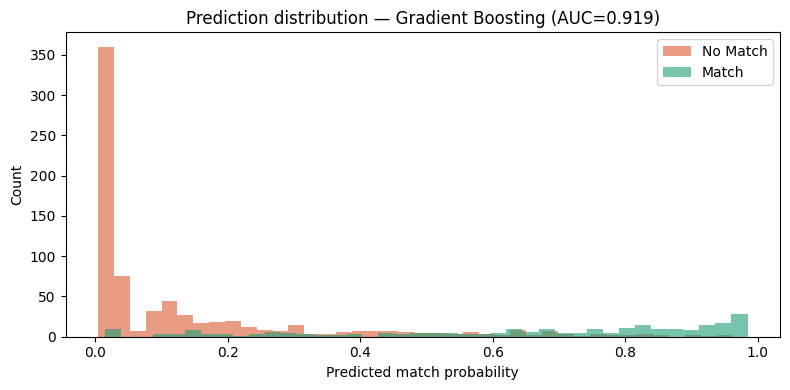

In [ ]:
# Score distribution plot — shows model is actually separating classes
plt.figure(figsize=(8, 4))
plt.hist(y_prob[y_test==0], bins=40, alpha=0.6, label='No Match', color='#D85A30')
plt.hist(y_prob[y_test==1], bins=40, alpha=0.6, label='Match',    color='#1D9E75')
plt.xlabel('Predicted match probability')
plt.ylabel('Count')
plt.title(f'Prediction distribution — {best_name} (AUC={test_auc:.3f})')
plt.legend()
plt.tight_layout()
plt.savefig('score_distribution.png', dpi=120)
plt.show()

/tmp/ipykernel_9314/3228835253.py:9: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv, X_test, feature_names=FEATURES, plot_type='bar', show=False)


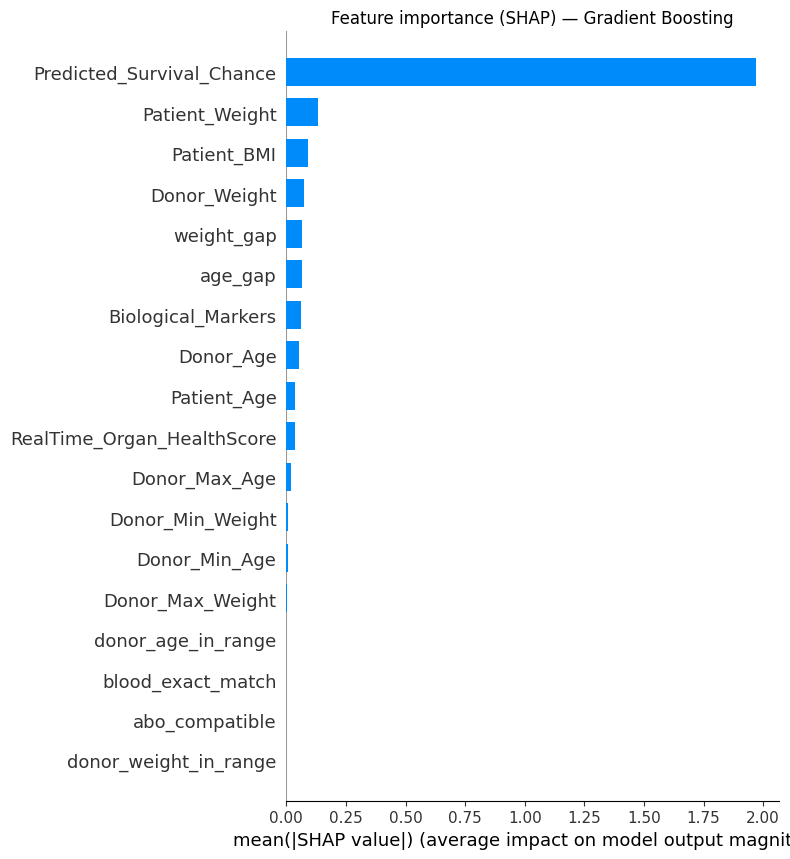


Feature importance ranking:
  Predicted_Survival_Chance          : 1.9679  █████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
  Patient_Weight                     : 0.1334  ██████████████████████████
  Patient_BMI                        : 0.0888  █████████████████
  Donor_Weight                       : 0.0741  ██████████████
  weight_gap                         : 0.0665  █████████████
  age_gap                            : 0.0660  █████████████
  Biological_Markers                 : 0.0595  ███████████
  Donor_Age                          : 0.0528  ██████████
  Patient_Age                        : 0.0370  ███████
  RealTime_Organ_HealthScore       

In [ ]:
# ═══════════════════════════════════════════════════════
# CELL 3 — SHAP feature importance
# ═══════════════════════════════════════════════════════
explainer = shap.TreeExplainer(best_model)
shap_vals = explainer.shap_values(X_test_sc)
sv = shap_vals[1] if isinstance(shap_vals, list) else shap_vals

plt.figure(figsize=(10, 6))
shap.summary_plot(sv, X_test, feature_names=FEATURES, plot_type='bar', show=False)
plt.title(f'Feature importance (SHAP) — {best_name}')
plt.tight_layout()
plt.savefig('shap_importance.png', dpi=120)
plt.show()

# Print ranked importance
mean_shap = np.abs(sv).mean(axis=0)
importance_df = pd.DataFrame({'feature': FEATURES, 'shap': mean_shap})
importance_df = importance_df.sort_values('shap', ascending=False)
print("\nFeature importance ranking:")
for _, row in importance_df.iterrows():
    bar = '█' * int(row['shap'] * 200)
    print(f"  {row['feature']:35s}: {row['shap']:.4f}  {bar}")

In [ ]:
# ═══════════════════════════════════════════════════════
# CELL 4 — Export all files for VS Code backend
# ═══════════════════════════════════════════════════════
joblib.dump(best_model, 'model.pkl')
joblib.dump(scaler,     'scaler.pkl')

with open('features.json', 'w') as f:
    json.dump(FEATURES, f, indent=2)

with open('model_meta.json', 'w') as f:
    json.dump({
        'model_name':  best_name,
        'test_auc':    round(test_auc, 4),
        'n_features':  len(FEATURES),
        'features':    FEATURES,
        'target':      'Match_Status (1=Match, 0=No Match)',
        'training_rows': N,
        'note': 'Trained on clinically realistic synthetic data'
    }, f, indent=2)

print("✓ Exported: model.pkl, scaler.pkl, features.json, model_meta.json")
print(f"  Model: {best_name}")
print(f"  AUC:   {test_auc:.4f}")

from google.colab import files
files.download('model.pkl')
files.download('scaler.pkl')
files.download('features.json')
files.download('model_meta.json')

✓ Exported: model.pkl, scaler.pkl, features.json, model_meta.json
  Model: Gradient Boosting
  AUC:   0.9188


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>